# Lab 01: arrays, tensores e regressão linear

**BCC406/PCC177 | Redes Neurais e Aprendizagem em Profundidade**  
**Tipo:** exercício extraclasse individual, com partes `ToDo` para entrega.

**Nome:** <u>Marcus</u><br>
**Matrícula:** <u></u>

Neste Lab você irá:

1. manipular arrays NumPy e tensores PyTorch;
2. distinguir operações elemento a elemento, produto interno e produto matricial;
3. visualizar como uma transformação linear altera o espaço;
4. treinar uma regressão linear em PyTorch com o conjunto Diabetes;
5. separar treino, validação e teste sem vazamento de dados;
6. avaliar o modelo com MSE, MAE e $R^2$;
7. realizar, como desafio, validação cruzada.

O conjunto Diabetes é um conjunto real, pequeno e distribuído com o scikit-learn. O alvo representa uma medida quantitativa da progressão da doença um ano após a medição inicial. Este Lab tem finalidade didática e não deve ser usado para diagnóstico ou decisão clínica.



## 1. Configuração e reprodutibilidade


In [1]:
%pip install matplotlib
%pip install scikit-learn
%pip install torch
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

SEMENTE = 42
random.seed(SEMENTE)
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
PyTorch: 2.14.0+cu130
Dispositivo: cpu


## 2. NumPy: forma, tipo e indexação

Um array é descrito por sua forma (`shape`), número de dimensões (`ndim`), quantidade de elementos (`size`) e tipo (`dtype`). Esses atributos ajudam a diagnosticar a maior parte dos erros de dimensão em modelos.


In [2]:
a = np.arange(24, dtype=np.float32).reshape(2, 3, 4) # 0 to 24. matrix with 2 columns, 3lines x 4columns for column
print(a)
print("shape:", a.shape, "| ndim:", a.ndim, "| size:", a.size)
print("dtype:", a.dtype, "| bytes por elemento:", a.itemsize)
print("segunda matriz, última coluna:", a[1, :, -1])


[[[ 0.  1.  2.  3.]
  [ 4.  5.  6.  7.]
  [ 8.  9. 10. 11.]]

 [[12. 13. 14. 15.]
  [16. 17. 18. 19.]
  [20. 21. 22. 23.]]]
shape: (2, 3, 4) | ndim: 3 | size: 24
dtype: float32 | bytes por elemento: 4
segunda matriz, última coluna: [15. 19. 23.]


### ToDo 1 (8 pontos)

Crie um array `cubo` de forma `(3, 3, 3)` contendo os inteiros de 0 a 26. Em seguida:

1. mostre a fatia central `cubo[:, 1, :]`;
2. troque todos os números pares por `-1`, sem escrever um laço `for`;
3. explique a diferença entre `shape`, `ndim` e `size`.


In [3]:
cubo = np.arange(27, dtype=np.float32).reshape(3,3,3)
print(cubo)
print(f"Fatia central: {cubo[:, 1, :]}")
cubo = np.where(cubo % 2 == 0, -1, cubo)
print(f"Números pares substituídos por -1: {cubo}")

[[[ 0.  1.  2.]
  [ 3.  4.  5.]
  [ 6.  7.  8.]]

 [[ 9. 10. 11.]
  [12. 13. 14.]
  [15. 16. 17.]]

 [[18. 19. 20.]
  [21. 22. 23.]
  [24. 25. 26.]]]
Fatia central: [[ 3.  4.  5.]
 [12. 13. 14.]
 [21. 22. 23.]]
Números pares substituídos por -1: [[[-1.  1. -1.]
  [ 3. -1.  5.]
  [-1.  7. -1.]]

 [[ 9. -1. 11.]
  [-1. 13. -1.]
  [15. -1. 17.]]

 [[-1. 19. -1.]
  [21. -1. 23.]
  [-1. 25. -1.]]]


### Reshape, views e cópias

`reshape` pode retornar uma visão que compartilha memória com o array original. `copy` cria armazenamento independente. Antes de alterar dados, é importante saber qual comportamento se deseja.


In [4]:
original = np.arange(6)
visao = original.reshape(2, 3)
copia = visao.copy()
visao[0, 0] = 99
copia[0, 1] = -5
print("original:", original)
print("visão:\n", visao)
print("cópia:\n", copia)


original: [99  1  2  3  4  5]
visão:
 [[99  1  2]
 [ 3  4  5]]
cópia:
 [[ 0 -5  2]
 [ 3  4  5]]


### Broadcasting

O NumPy compara as dimensões da direita para a esquerda. Duas dimensões são compatíveis quando são iguais ou quando uma delas vale 1.


In [5]:
X = np.arange(12).reshape(3, 4)
deslocamento_colunas = np.array([10, 20, 30, 40])
escala_linhas = np.array([1, 10, 100]).reshape(3, 1)

print("X + vetor (broadcast nas linhas):\n", X + deslocamento_colunas)
print("X * coluna (broadcast nas colunas):\n", X * escala_linhas)


X + vetor (broadcast nas linhas):
 [[10 21 32 43]
 [14 25 36 47]
 [18 29 40 51]]
X * coluna (broadcast nas colunas):
 [[   0    1    2    3]
 [  40   50   60   70]
 [ 800  900 1000 1100]]


### ToDo 2 (12 pontos)

Considere `lote = np.ones((8, 3, 32, 32))`, que representa 8 imagens RGB.

1. Crie `media_rgb` com forma compatível para subtrair uma média diferente de cada canal.
2. Faça a subtração usando broadcasting.
3. Informe a forma final.
4. Explique por que um vetor com forma `(3,)` não é alinhado automaticamente ao eixo dos canais nesse caso.


In [6]:
# ToDo 2
lote = np.ones((8, 3, 32, 32), dtype=np.float32) # 8 conjuntos = cada conjunto tem 3 matrizes = cada matriz tem 32×32.
#print(lote[0, 0])
media_rgb = np.array([0.5, 0.5, 0.5]).reshape(1, 3, 1, 1)
print(f"Media RGB: {media_rgb}")
lote_centralizado = lote - media_rgb
print(f"Subtração:{lote_centralizado.shape}")
print(f"Forma final: {lote_centralizado.shape}")
print("Valor:", lote_centralizado[0, :, 0, 0])


Media RGB: [[[[0.5]]

  [[0.5]]

  [[0.5]]]]
Subtração:(8, 3, 32, 32)
Forma final: (8, 3, 32, 32)
Valor: [0.5 0.5 0.5]


## 3. Operações vetoriais e matriciais


In [7]:
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 5.0, 6.0])
A = np.array([[1.0, 2.0, 0.0], [0.0, -1.0, 3.0]])

print("produto elemento a elemento:", u * v)
print("produto interno u @ v:", u @ v)
print("produto matriz-vetor A @ u:", A @ u)
print("formas:", u.shape, v.shape, A.shape, (A @ u).shape)


produto elemento a elemento: [ 4. 10. 18.]
produto interno u @ v: 32.0
produto matriz-vetor A @ u: [5. 7.]
formas: (3,) (3,) (2, 3) (2,)


### ToDo 3 (10 pontos)

Sem executar primeiro, determine a forma de cada resultado. Depois confirme com NumPy e explique cada incompatibilidade encontrada.

1. `(5, 3) @ (3,)`
2. `(4, 5, 3) @ (3, 2)`
3. `(5, 3) * (3,)`
4. `(5, 3) @ (5,)`

Inclua sua previsão, o código de verificação e a explicação nesta seção.


In [8]:
# 1) Previsao: (5,)
(np.ones((5, 3)) @ np.ones((3,))).shape
# (5,) OK

# 2) Previsao: Nao consegui prever
(np.ones((4, 5, 3)) @ np.ones((3, 2))).shape
# (4, 5, 2)

# 3) Previsao (5,3)
(np.ones((5, 3)) * np.ones((3,))).shape
# (5, 3) OK

# 4) (5, 3)
(np.ones((5, 3)) @ np.ones((5,))).shape
# ValueError -> errei, pois embora tenha estranhado, não reparei que o 5 excedia o 3 impossibilitando o cálculo.

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 3)

### 4. Transformação linear do espaço


In [ ]:
theta = np.linspace(0, 2 * np.pi, 300)  # 300 valores de 0 a 2pi
circulo = np.vstack([np.cos(theta), np.sin(theta)]) # cria um circulo e o empilha, com 2 x 300 pontos
base = np.eye(2) # matriz identidade

A = np.array([[1.5, 0.8], [0.2, 0.7]])
circulo_transformado = A @ circulo # multiplica a matriz para o circulo fazendo a transformacao (deforma-o transformando numa ecliose)
base_transformada = A @ base

fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for ax in eixos:
    ax.axhline(0, color="0.85", linewidth=1)
    ax.axvline(0, color="0.85", linewidth=1)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

eixos[0].plot(circulo[0], circulo[1], color="#962038")
eixos[0].quiver([0, 0], [0, 0], base[0], base[1],
                angles="xy", scale_units="xy", scale=1, color=["#34383C", "#962038"])
eixos[0].set_title("Espaço original")

eixos[1].plot(circulo_transformado[0], circulo_transformado[1], color="#962038")
eixos[1].quiver([0, 0], [0, 0], base_transformada[0], base_transformada[1],
                angles="xy", scale_units="xy", scale=1, color=["#34383C", "#962038"])
eixos[1].set_title("Após multiplicação por A")

limite = 2.6
for ax in eixos:
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
plt.tight_layout()
plt.show()

print("A =\n", A)
print("det(A) =", np.linalg.det(A))
print("A e1 =", base_transformada[:, 0])
print("A e2 =", base_transformada[:, 1])


### ToDo 4 (15 pontos)

Crie e visualize três matrizes diferentes:

1. uma rotação de $45^\circ$;
2. uma reflexão no eixo horizontal;
3. uma transformação singular, com determinante zero.

Para cada matriz, registre o determinante e descreva o efeito sobre o círculo, a orientação e a área. No caso singular, explique por que não existe matriz inversa. Reutilize o código de visualização acima em uma função para evitar repetição.


In [ ]:
# ToDo 4: implemente uma função de visualização e teste as três matrizes.
def exibe_resultado(eixos, A, base_transformada, limite=2.6):
    for ax in eixos:
        ax.set_xlim(-limite, limite)
        ax.set_ylim(-limite, limite)
    plt.tight_layout()
    plt.show()
    
    print("A =\n", A)
    print("det(A) =", np.linalg.det(A))
    print("A e1 =", base_transformada[:, 0])
    print("A e2 =", base_transformada[:, 1])

    
def transforma_matriz(circulo, circulo_transformado, base, base_transformada, titulo1, titulo2):
    fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
    for ax in eixos:
        ax.axhline(0, color="0.85", linewidth=1)
        ax.axvline(0, color="0.85", linewidth=1)
        ax.set_aspect("equal")
        ax.grid(alpha=0.2)
    
    eixos[0].plot(circulo[0], circulo[1], color="#962038")
    eixos[0].quiver([0, 0], [0, 0], base[0], base[1],
                    angles="xy", scale_units="xy", scale=1, color=["#34383C", "#962038"])
    eixos[0].set_title(titulo1)
    
    eixos[1].plot(circulo_transformado[0], circulo_transformado[1], color="#962038")
    eixos[1].quiver([0, 0], [0, 0], base_transformada[0], base_transformada[1],
                    angles="xy", scale_units="xy", scale=1, color=["#34383C", "#962038"])
    eixos[1].set_title(titulo2)
    return eixos

# Rotacao 45 graus.
theta = np.linspace(0, 2 * np.pi, 300)
circulo = np.vstack([np.cos(theta), np.sin(theta)]) 
base = np.eye(2)

A = np.array([[0.7, -0.7], [0.7, 0.7]]) # sin e cos de 45 sao aproximadamente 0.7 
circulo_transformado = A @ circulo 
base_transformada = A @ base

eixos1 = transforma_matriz(circulo, circulo_transformado, base, base_transformada, "Matriz1: figura original", "Matriz1: figura após rotação de 45 graus")
exibe_resultado(eixos1, A, base_transformada)

# reflexao horizontal
theta = np.linspace(0, 2 * np.pi, 300)
circulo = np.vstack([np.cos(theta), np.sin(theta)]) 
base = np.eye(2)

A = np.array([[1, 0], [0, -1]]) 
circulo_transformado = A @ circulo 
base_transformada = A @ base

eixos1 = transforma_matriz(circulo, circulo_transformado, base, base_transformada, "Matriz1: figura original", "Matriz1: figura após reflexao sobre o eixo horizontal")
exibe_resultado(eixos1, A, base_transformada)

# transformacao singular com determinante 0
theta = np.linspace(0, 2 * np.pi, 300)
circulo = np.vstack([np.cos(theta), np.sin(theta)]) 
base = np.eye(2)

A = np.array([[0, 1], [0, 1]]) 
circulo_transformado = A @ circulo 
base_transformada = A @ base

eixos1 = transforma_matriz(circulo, circulo_transformado, base, base_transformada, "Matriz1: figura original", "Matriz1: figura após transformacao com determinante 0")
exibe_resultado(eixos1, A, base_transformada)


## 5. De NumPy para PyTorch

NumPy e PyTorch compartilham várias operações e regras de broadcasting. PyTorch acrescenta execução em aceleradores e autodiferenciação. Um tensor convertido com `torch.from_numpy` pode compartilhar memória com o array original.


In [ ]:
# anotacao para estudo: usado para operações vetoriais que exigem velocidade. 
# Pytorch => framework usado para deeplearning e que permite execucao em gpu. E usa tensores (matrizes com mais de 3 dimensoes) uma imagem, rgb, é um tensor, por exemplo - uma pilha de matrizes.
array_np = np.arange(6, dtype=np.float32).reshape(2, 3)
tensor_torch = torch.from_numpy(array_np)
tensor_torch[0, 0] = 100

print("NumPy:\n", array_np)
print("PyTorch:\n", tensor_torch)
print("produto matricial:\n", tensor_torch @ tensor_torch.T)


### ToDo 5 (10 pontos)

Repita em PyTorch as operações da seção 3 usando `torch.tensor`, `*`, `@` e `.T`. Verifique com `np.allclose` que os resultados NumPy e PyTorch coincidem. Em seguida, mova os tensores para `DEVICE` e informe em qual dispositivo eles ficaram.


In [13]:
# ToDo 5
array_numpy = np.array([1.0, 2.0, 3.0])
array_numpy2 = np.array([4.0, 5.0, 6.0])
matriz_numpy = np.array([[1.0, 2.0, 0.0], [0.0, -1.0, 3.0]])
resultado_a_comparar_np = array_numpy * array_numpy2
# tensores:
tensor_u = torch.tensor(array_numpy)
tensor_v = torch.tensor(array_numpy2)
tensor_A = torch.tensor(matriz_numpy)
resultado_a_comparar_torch = tensor_u * tensor_v

print("produto elemento a elemento:", tensor_u * tensor_v)
print("produto interno u @ v:", tensor_u @ tensor_v)
print("produto matriz-vetor A @ u:", tensor_A @ tensor_u)
print("formas:", tensor_u.shape, tensor_v.shape, tensor_A.shape, (tensor_A @ tensor_u).shape)

print(f"os codigos estão rodando em: {tensor_u.device}")

print(f"os resultados coincidem? {np.allclose(resultado_a_comparar_np, resultado_a_comparar_torch)}")



produto elemento a elemento: tensor([ 4., 10., 18.], dtype=torch.float64)
produto interno u @ v: tensor(32., dtype=torch.float64)
produto matriz-vetor A @ u: tensor([5., 7.], dtype=torch.float64)
formas: torch.Size([3]) torch.Size([3]) torch.Size([2, 3]) torch.Size([2])
os codigos estão rodando em: cpu
os resultados coincidem? True


### Autodiferenciação

Para $f(\mathbf{x})=\sum_i x_i^2$, temos $\nabla_{\mathbf{x}}f=2\mathbf{x}$. O PyTorch registra o grafo das operações quando `requires_grad=True` e calcula o gradiente com `backward()`.


In [14]:
x = torch.tensor([1.0, -2.0, 3.0], requires_grad=True)
f = (x ** 2).sum()
f.backward()
print("f(x) =", f.item())
print("gradiente calculado:", x.grad)
print("gradiente esperado:", 2 * x.detach())


f(x) = 14.0
gradiente calculado: tensor([ 2., -4.,  6.])
gradiente esperado: tensor([ 2., -4.,  6.])


### ToDo 6 (10 pontos)

Defina em PyTorch $g(\mathbf{x})=\lVert A\mathbf{x}-\mathbf{b}\rVert_2^2$ para uma matriz `A` de forma `(4, 3)`, `x` de forma `(3,)` e `b` de forma `(4,)`. Calcule $\nabla_\mathbf{x}g$ com `backward()` e confira o resultado com a expressão analítica $2A^\top(A\mathbf{x}-\mathbf{b})$.


In [27]:
# ToDo 6
A = torch.randn(4, 3)
x = torch.randn(3, requires_grad=True)
b = torch.randn(4)
g = torch.norm(A @ x - b, p=2) ** 2
g.backward()
print(f"Gradiente calculado: {x.grad}")
x.detach()
print(f"Gradiente esperado: {2 * A.T @ (A@x-b)}")


Gradiente calculado: tensor([  2.6870, -15.5061,   4.4726])
Gradiente esperado: tensor([  2.6870, -15.5061,   4.4726], grad_fn=<MvBackward0>)


## 6. Regressão linear com o conjunto Diabetes

Usaremos dez atributos quantitativos para prever uma medida da progressão da doença. O modelo é

$$\hat{y}=\mathbf{x}^{\top}\mathbf{w}+b.$$

O objetivo é praticar o fluxo experimental. A partição de **treino** ajusta os pesos, a de **validação** escolhe configurações e a de **teste** é consultada apenas ao final para estimar generalização.


In [29]:
diabetes = load_diabetes()
X_np = diabetes.data.astype(np.float32) # dados de pessoas 442 pessoas -> 10 features
y_np = diabetes.target.astype(np.float32).reshape(-1, 1) # respostas dessas pessoas -> 442 -> 1 resposta.

print(diabetes.DESCR.split("\n")[0])
print("X:", X_np.shape, "| y:", y_np.shape)
print("atributos:", list(diabetes.feature_names))
print("alvo mínimo/médio/máximo:", y_np.min(), y_np.mean(), y_np.max())


.. _diabetes_dataset:
X: (442, 10) | y: (442, 1)
atributos: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
alvo mínimo/médio/máximo: 25.0 152.13348 346.0


### Separação e padronização sem vazamento

Primeiro reservamos 15% para teste. Depois separamos aproximadamente 15% do total para validação. O `StandardScaler` é ajustado **somente no treino**. Usar todos os dados para calcular média e desvio permitiria que informação das partições de validação e teste influenciasse o treinamento.


In [30]:
# treinamento
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_np, y_np, test_size=0.15, random_state=SEMENTE
) # 15 para teste e 85 para treino
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_treino, y_treino, test_size=0.1765, random_state=SEMENTE
) # separa denovo 15 para validacao do treinamento

scaler = StandardScaler() # padroniza os dados com base na variancia para que o gradiente n tenda a valores de escala maior
X_treino = scaler.fit_transform(X_treino).astype(np.float32) # calcula a media e desvio padrao dos dados e aplica a padronizacao. O fit acontece so nos dados de treino, pois evita o vazamento ja que o objeto poderia ver.
# validacao
X_valid = scaler.transform(X_valid).astype(np.float32) # aplica a mesma formula mas com os valores de desvio e media ja calculados
# teste
X_teste = scaler.transform(X_teste).astype(np.float32) # normaliza os dados de teste tmb.

print("treino:", X_treino.shape, y_treino.shape)
print("validação:", X_valid.shape, y_valid.shape)
print("teste:", X_teste.shape, y_teste.shape)
print("média dos atributos no treino:", np.round(X_treino.mean(axis=0), 4))


treino: (308, 10) (308, 1)
validação: (67, 10) (67, 1)
teste: (67, 10) (67, 1)
média dos atributos no treino: [ 0. -0. -0.  0. -0.  0. -0.  0.  0. -0.]


In [32]:
def para_tensor(array):
    """Converte de numpy para pytorch eficientemente para dps usar o gradiente"""
    return torch.as_tensor(array, dtype=torch.float32, device=DEVICE)

Xtr, ytr = para_tensor(X_treino), para_tensor(y_treino)
Xva, yva = para_tensor(X_valid), para_tensor(y_valid)
Xte, yte = para_tensor(X_teste), para_tensor(y_teste)


### Modelo e laço de treinamento

`nn.Linear(10, 1)` implementa exatamente $X\mathbf{w}+b$. Durante cada época, calculamos previsões, MSE, gradientes e atualização dos parâmetros. A validação é calculada sem registrar gradientes.


In [39]:
def treinar_modelo(taxa=0.01, epocas=500, semente=42):
    """
    # ============================================================
    # RESUMO — PRÉ-PROCESSAMENTO E TREINAMENTO para consulta/estudo
    # ============================================================
    
    # ---------------------------
    # 1. X, y e dimensões
    # ---------------------------
    # X = entradas/features.
    # y = alvo/resultado que queremos prever.
    #
    # Exemplo:
    # X.shape = (310, 10)
    #   310 = quantidade de exemplos/amostras
    #   10  = quantidade de features por exemplo
    #
    # Cada linha de X representa um exemplo:
    #
    #   exemplo 1 -> [x1, x2, ..., x10]
    #   exemplo 2 -> [x1, x2, ..., x10]
    #
    # y.shape = (310, 1)
    # Existe 1 alvo para cada exemplo.
    
    
    # ---------------------------
    # 2. nn.Linear
    # ---------------------------
    # nn.Linear(10, 1)
    #
    # Significa:
    #   10 entradas/features -> 1 saída
    #
    # Na regressão linear:
    #
    #   ŷ = w1*x1 + w2*x2 + ... + w10*x10 + b
    #
    # Portanto:
    #   10 pesos + 1 bias = 11 parâmetros.
    #
    # O número de exemplos NÃO entra no nn.Linear.
    # Os 310 exemplos são processados pelo mesmo modelo.
    
    
    # ---------------------------
    # 3. Batch e multiplicação de matrizes
    # ---------------------------
    # Se:
    #
    #   xb.shape = (32, 10)
    #   W.shape  = (10, 1)
    #
    # então:
    #
    #   (32 x 10) @ (10 x 1) = (32 x 1)
    #
    # Ou seja, o modelo produz 32 previsões de uma vez.
    #
    # Isso evita um for em Python para cada exemplo e permite
    # operações vetorizadas, que são muito mais eficientes.
    # Em GPU/CUDA, essas operações podem ser altamente paralelizadas.
    
    
    # ---------------------------
    # 4. StandardScaler
    # ---------------------------
    # O scaler padroniza cada feature aproximadamente para:
    #
    #   média = 0
    #   desvio-padrão = 1
    #
    # Fórmula:
    #
    #   x_novo = (x - média) / desvio_padrão
    #
    # IMPORTANTE:
    #
    #   fit()       -> APRENDE média e desvio-padrão
    #   transform() -> APLICA média e desvio-padrão já aprendidos
    #
    # No pipeline correto:
    #
    #   scaler.fit(X_treino)
    #   X_treino = scaler.transform(X_treino)
    #   X_valid  = scaler.transform(X_valid)
    #   X_teste  = scaler.transform(X_teste)
    #
    # Ou:
    #
    #   X_treino = scaler.fit_transform(X_treino)
    #   X_valid  = scaler.transform(X_valid)
    #   X_teste  = scaler.transform(X_teste)
    #
    # NÃO fazer fit na validação, teste ou em um novo paciente.
    #
    # Motivo:
    # O scaler deve aprender suas métricas SOMENTE com o treino.
    # Se fizermos fit nos dados de avaliação, informações desses dados
    # entram no pipeline -> DATA LEAKAGE.
    #
    # Para um paciente novo:
    #
    #   scaler.transform(X_novo)
    #
    # Usa a mesma "régua" aprendida no treinamento.
    
    
    # ---------------------------
    # 5. DataLoader e batches
    # ---------------------------
    # batch_size = 32
    #
    # Significa que o modelo processa 32 exemplos por vez.
    #
    # Se temos 320 exemplos:
    #
    #   320 / 32 = 10 batches por época
    #
    # Cada batch gera uma atualização dos parâmetros:
    #
    #   batch 1 -> step()
    #   batch 2 -> step()
    #   ...
    #   batch 10 -> step()
    #
    # Portanto:
    #
    #   10 steps por época
    #
    # Com 500 épocas:
    #
    #   10 * 500 = 5000 steps
    #
    # Uma época = passar por TODOS os exemplos do treino uma vez.
    # Um step = uma atualização dos parâmetros.
    
    
    # ---------------------------
    # 6. Forward
    # ---------------------------
    # pred = modelo(xb)
    #
    # É a passagem dos dados pelo modelo para produzir previsões.
    #
    # Exemplo:
    #
    #   X -> Linear -> predição
    #
    # Na regressão:
    #
    #   pred = XW + b
    
    
    # ---------------------------
    # 7. Loss / MSE
    # ---------------------------
    # perda = perda_fn(pred, yb)
    #
    # MSE = Mean Squared Error
    #
    #   MSE = média((y_real - y_pred)^2)
    #
    # Mede o quanto as previsões estão distantes dos valores reais.
    #
    # Quanto menor a MSE, menor o erro médio quadrático.
    
    
    # ---------------------------
    # 8. backward()
    # ---------------------------
    # perda.backward()
    #
    # NÃO atualiza os pesos.
    #
    # O backward calcula os gradientes da perda em relação
    # a cada parâmetro do modelo.
    #
    # Para 10 pesos + 1 bias:
    #
    #   dL/dw1
    #   dL/dw2
    #   ...
    #   dL/dw10
    #   dL/db
    #
    # Cada gradiente responde aproximadamente:
    #
    # "Se eu alterar este parâmetro, como a perda muda?"
    #
    # O conjunto desses gradientes forma o gradiente do modelo.
    
    
    # ---------------------------
    # 9. optimizer.step()
    # ---------------------------
    # otimizador.step()
    #
    # USA os gradientes calculados pelo backward() para
    # efetivamente alterar os pesos e o bias.
    #
    # Regra simplificada do Gradient Descent:
    #
    #   parâmetro_novo =
    #       parâmetro_atual - learning_rate * gradiente
    #
    # Exemplo:
    #
    #   w = 2
    #   gradiente = 5
    #   lr = 0.01
    #
    #   w_novo = 2 - 0.01*5
    #          = 1.95
    #
    # Se o gradiente for negativo:
    #
    #   w = 2
    #   gradiente = -3
    #   lr = 0.01
    #
    #   w_novo = 2 - 0.01*(-3)
    #          = 2.03
    #
    # O sinal do gradiente determina a direção do update.
    #
    # RESUMO:
    #
    #   backward() -> descobre a direção/tamanho do gradiente
    #   step()     -> dá o passo e modifica os parâmetros
    
    
    # ---------------------------
    # 10. Gradiente é um vetor
    # ---------------------------
    # Cada peso pode ter um gradiente diferente.
    #
    # Exemplo:
    #
    #   gradiente = [4, -2]
    #
    # Para:
    #
    #   w1 = 2
    #   w2 = 5
    #
    # com lr = 0.1:
    #
    #   w1 = 2 - 0.1*(4)  = 1.6
    #   w2 = 5 - 0.1*(-2) = 5.2
    #
    # Portanto, os parâmetros são atualizados simultaneamente,
    # mas cada um pode se mover em direção e magnitude diferentes.
    #
    # Matematicamente:
    #
    #   W_novo = W_atual - lr * gradiente
    
    
    # ---------------------------
    # 11. zero_grad()
    # ---------------------------
    # otimizador.zero_grad()
    #
    # O PyTorch ACUMULA gradientes por padrão.
    #
    # Exemplo:
    #
    #   batch 1 -> gradiente = 3
    #   batch 2 -> gradiente = -1
    #
    # Sem zero_grad():
    #
    #   gradiente acumulado = 3 + (-1) = 2
    #
    # O step() usaria 2, e não apenas -1.
    #
    # Por isso o ciclo normalmente é:
    #
    #   zero_grad()
    #   backward()
    #   step()
    #
    # Ou seja:
    #
    #   1. limpa gradientes antigos
    #   2. calcula novos gradientes
    #   3. atualiza os parâmetros
    
    
    # ---------------------------
    # 12. Ordem completa do treinamento
    # ---------------------------
    # Para cada batch:
    #
    #   xb, yb
    #      ↓
    #   pred = modelo(xb)       # FORWARD
    #      ↓
    #   perda = MSE(pred, yb)   # calcula erro
    #      ↓
    #   zero_grad()             # limpa gradientes anteriores
    #      ↓
    #   backward()              # calcula gradientes
    #      ↓
    #   step()                  # atualiza pesos/bias
    #
    # Esse processo se repete para todos os batches.
    # Depois começa a próxima época.
    
    
    # ---------------------------
    # 13. Treino x validação x teste
    # ---------------------------
    # TREINO:
    #   usado para calcular gradientes e atualizar pesos.
    #
    # VALIDAÇÃO:
    #   usada durante o desenvolvimento para avaliar o modelo
    #   e ajudar na escolha de hiperparâmetros.
    #   Não atualiza os pesos.
    #
    # TESTE:
    #   conjunto reservado para a avaliação final.
    #   Idealmente não deve influenciar as decisões do desenvolvimento.
    #
    # Importante:
    #   validação NÃO é completamente "intocável".
    #   Ela pode ser consultada durante o desenvolvimento.
    #   O teste é que deve ficar reservado para a avaliação final.
    
    
    # ---------------------------
    # 14. model.train() x model.eval()
    # ---------------------------
    # model.train()
    #   coloca o modelo em modo de treinamento.
    #
    # model.eval()
    #   coloca o modelo em modo de avaliação.
    #
    # Em uma nn.Linear simples, isso não muda praticamente nada,
    # mas é importante porque outras camadas, como Dropout e
    # BatchNorm, possuem comportamentos diferentes nesses modos.
    
    
    # ---------------------------
    # 15. torch.no_grad()
    # ---------------------------
    # with torch.no_grad():
    #
    # Durante a validação não precisamos calcular gradientes.
    #
    # Isso economiza memória e processamento.
    #
    # Como não haverá backward() nem step(), os pesos não são alterados.
    
    
    # ---------------------------
    # 16. Histórico de treino/validação
    # ---------------------------
    # historico["treino"].append(...)
    # historico["validacao"].append(...)
    #
    # Guarda a MSE de cada época.
    #
    # Serve posteriormente para:
    #   - visualizar a evolução do treinamento
    #   - comparar hiperparâmetros
    #   - verificar convergência
    #   - identificar possíveis sinais de overfitting
    #
    # [-1] = último valor do histórico.
    
    
    # ============================================================
    # VISÃO GERAL
    # ============================================================
    #
    # DADOS
    #   ↓
    # X_train / X_valid / X_test
    #   ↓
    # StandardScaler
    #   ↓
    # batches
    #   ↓
    # modelo (Linear)
    #   ↓
    # previsão
    #   ↓
    # MSE
    #   ↓
    # backward() → calcula gradientes
    #   ↓
    # step() → atualiza pesos
    #   ↑
    # zero_grad() → limpa gradientes anteriores
    #
    # O treinamento repete isso por vários batches e épocas.
    #
    # FRASE PARA LEMBRAR:
    #
    #   "Forward calcula a previsão.
    #    Loss mede o erro.
    #    Backward calcula como cada parâmetro influencia o erro.
    #    Step atualiza os parâmetros.
    #    Zero_grad limpa os gradientes anteriores."
    # ============================================================
    """

    torch.manual_seed(semente)
    modelo = nn.Linear(Xtr.shape[1], 1).to(DEVICE)
    perda_fn = nn.MSELoss()
    otimizador = torch.optim.SGD(modelo.parameters(), lr=taxa)
    historico = {"treino": [], "validacao": []}
    loader_treino = DataLoader(
        TensorDataset(Xtr, ytr), batch_size=32, shuffle=True,
        generator=torch.Generator().manual_seed(semente)
    )

    for _ in range(epocas):
        modelo.train()
        soma, quantidade = 0.0, 0
        for xb, yb in loader_treino:
            pred = modelo(xb)
            perda = perda_fn(pred, yb)
            otimizador.zero_grad()
            perda.backward()
            otimizador.step()
            soma += perda.item() * len(xb)
            quantidade += len(xb)

        modelo.eval()
        with torch.no_grad():
            perda_valid = perda_fn(modelo(Xva), yva).item()
        historico["treino"].append(soma / quantidade)
        historico["validacao"].append(perda_valid)

    return modelo, historico

modelo, historico = treinar_modelo()
print("MSE final de treino:", round(historico["treino"][-1], 2))
print("MSE final de validação:", round(historico["validacao"][-1], 2))


MSE final de treino: 2912.26
MSE final de validação: 2591.78


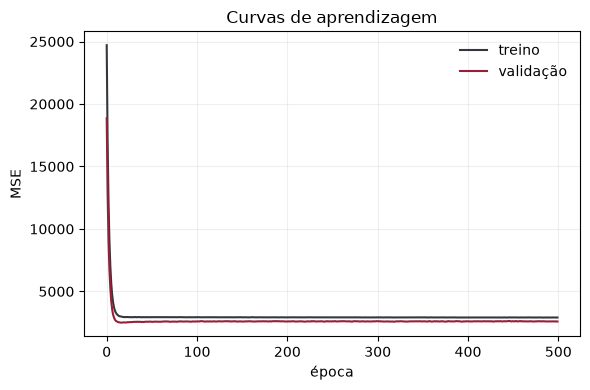

In [34]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(historico["treino"], label="treino", color="#34383C")
ax.plot(historico["validacao"], label="validação", color="#962038")
ax.set(xlabel="época", ylabel="MSE", title="Curvas de aprendizagem")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### Escolha da taxa de aprendizado pela validação

Executamos treinamentos independentes para cada taxa. O teste continua guardado. Em um estudo maior, também investigaríamos número de épocas, tamanho do lote e regularização.


In [35]:
taxas = [0.001, 0.01, 0.05]
resultados_validacao = []
modelos = {}

for taxa in taxas:
    candidato, hist = treinar_modelo(taxa=taxa, epocas=500, semente=SEMENTE)
    mse_valid = hist["validacao"][-1]
    resultados_validacao.append((taxa, mse_valid))
    modelos[taxa] = candidato

for taxa, mse in resultados_validacao:
    print(f"lr={taxa:<5} | MSE validação={mse:.2f}")

melhor_taxa = min(resultados_validacao, key=lambda item: item[1])[0]
melhor_modelo = modelos[melhor_taxa]
print("taxa escolhida:", melhor_taxa)


lr=0.001 | MSE validação=2571.49
lr=0.01  | MSE validação=2591.78
lr=0.05  | MSE validação=2553.04
taxa escolhida: 0.05


### Avaliação final

MSE e MAE são medidas de erro e devem ser minimizadas. $R^2=1$ indica predição perfeita; $R^2=0$ equivale, no conjunto avaliado, a sempre prever a média desse mesmo conjunto. Valores negativos são possíveis.


In [36]:
melhor_modelo.eval()
with torch.no_grad():
    pred_teste = melhor_modelo(Xte).cpu().numpy()

mse = mean_squared_error(y_teste, pred_teste)
mae = mean_absolute_error(y_teste, pred_teste)
r2 = r2_score(y_teste, pred_teste)
print(f"MSE teste: {mse:.2f}")
print(f"RMSE teste: {np.sqrt(mse):.2f}")
print(f"MAE teste: {mae:.2f}")
print(f"R² teste: {r2:.3f}")


MSE teste: 3191.63
RMSE teste: 56.49
MAE teste: 44.54
R² teste: 0.416


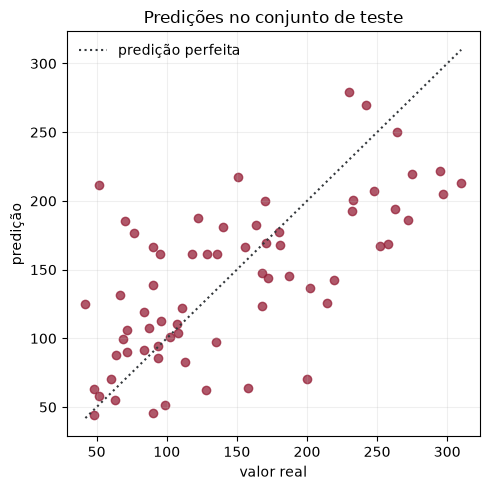

In [37]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_teste, pred_teste, alpha=0.75, color="#962038")
limites = [min(y_teste.min(), pred_teste.min()), max(y_teste.max(), pred_teste.max())]
ax.plot(limites, limites, color="#34383C", linestyle=":", label="predição perfeita")
ax.set(xlabel="valor real", ylabel="predição", title="Predições no conjunto de teste")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### ToDo 7 (20 pontos)

1. Identifique a taxa escolhida pela validação e compare as curvas das três taxas.
2. Explique por que a taxa não foi escolhida usando o teste.
3. Interprete MSE, MAE e $R^2$ obtidos. As métricas medem a mesma coisa?
4. Inspecione o gráfico de valor real versus predição. Em que região o modelo parece errar mais?
5. Compare o MSE de teste com um baseline que sempre prevê a média **do alvo de treino**. Implemente o baseline e discuta o resultado.


In [ ]:
# ToDo 7, item 5: implemente o baseline e calcule seu MSE.
pred_baseline = None
mse_baseline = None


### ToDo 8 (10 pontos)

Implemente a solução analítica com `torch.linalg.lstsq`. Acrescente uma coluna de 1 à matriz de treino para representar o viés. Avalie a solução no teste com o mesmo `scaler` e compare suas métricas e pesos com o modelo treinado por SGD.

Evite calcular $(X^TX)^{-1}$ explicitamente. `lstsq` é numericamente mais apropriado.


In [ ]:
# ToDo 8


## 7. Desafio: validação cruzada (bônus de 10 pontos)

Uma única divisão pode produzir uma estimativa sensível aos exemplos escolhidos. Na validação cruzada com $K$ partições, cada partição assume uma vez o papel de validação e as demais formam o treino.

Use `KFold(n_splits=5, shuffle=True, random_state=SEMENTE)` sobre o conjunto completo. Em cada fold:

1. ajuste um novo `StandardScaler` somente na parcela de treino daquele fold;
2. crie e treine um novo `nn.Linear`;
3. calcule MSE e $R^2$ na validação;
4. apresente média e desvio padrão das métricas.

Explique por que reutilizar o `scaler` ou o modelo entre folds seria um erro. Compare a média da validação cruzada com o resultado da divisão única, sem esperar que sejam idênticos.


In [ ]:
# ToDo bônus: validação cruzada com 5 folds.
kfold = KFold(n_splits=5, shuffle=True, random_state=SEMENTE)
resultados_cv = []


## Checklist antes da entrega

- Todas as células `ToDo` foram preenchidas.
- O notebook executa do início ao fim após reiniciar o ambiente.
- As saídas da última execução foram mantidas.
- Shapes e dispositivos foram conferidos.
- O `StandardScaler` foi ajustado apenas com dados de treino.
- O conjunto de teste não foi usado para escolher hiperparâmetros.
- Gráficos têm título e eixos identificados.
- As respostas interpretam os resultados e registram limitações.

O conjunto Diabetes é apropriado para aprender o procedimento, mas este experimento pequeno não sustenta conclusões clínicas. O modelo linear também impõe uma relação aditiva e linear entre os atributos e o alvo.
